In [1]:
!pip install tensorflow scikit-learn pandas numpy matplotlib -q
print("Done!")

Done!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


In [3]:
df = pd.read_csv('TMDB_movie_dataset_v11.csv')

drop_cols = ['backdrop_path', 'homepage', 'poster_path',
             'tagline', 'imdb_id', 'keywords']
df = df.drop(columns=drop_cols)
df = df[df['status'] == 'Released']
df = df.dropna(subset=['budget', 'revenue', 'genres', 'release_date', 'overview'])
df = df[df['budget'] > 0]
df = df[df['revenue'] > 0]
df = df.reset_index(drop=True)

df['roi'] = df['revenue'] / df['budget']
df['hit'] = (df['roi'] > 1).astype(int)

df['release_date'] = pd.to_datetime(df['release_date'])
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['primary_genre'] = df['genres'].str.split(',').str[0].str.strip()

le = LabelEncoder()
df['genre_encoded'] = le.fit_transform(df['primary_genre'])

df['log_budget'] = np.log1p(df['budget'])
df['log_popularity'] = np.log1p(df['popularity'])

feature_cols = ['log_budget', 'runtime', 'log_popularity',
                'vote_average', 'vote_count', 'release_month',
                'release_year', 'genre_encoded']

X = df[feature_cols].values
y = df['hit'].values

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set : {X_train.shape}")
print(f"Test set     : {X_test.shape}")

Training set : (9750, 8)
Test set     : (2438, 8)


In [4]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(8,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 11,905 (46.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [5]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()
acc = accuracy_score(y_test, y_pred)

print(f"\nNeural Network Accuracy: {acc*100:.2f}%")
print(f"\n{classification_report(y_test, y_pred, target_names=['Flop', 'Hit'])}")

Epoch 1/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6236 - loss: 0.6565 - val_accuracy: 0.6753 - val_loss: 0.5649
Epoch 2/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6701 - loss: 0.5868 - val_accuracy: 0.6986 - val_loss: 0.5448
Epoch 3/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6768 - loss: 0.5761 - val_accuracy: 0.6924 - val_loss: 0.5384
Epoch 4/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6819 - loss: 0.5703 - val_accuracy: 0.7314 - val_loss: 0.5261
Epoch 5/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6899 - loss: 0.5659 - val_accuracy: 0.7341 - val_loss: 0.5258
Epoch 6/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6949 - loss: 0.5586 - val_accuracy: 0.7198 - val_loss: 0.5241
Epoch 7/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6923 - loss: 0.5605 - val_accuracy: 0.7116 - val_loss: 0.5237
Epoch 8/100
259/259 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6998 - loss: 0.5541 - val_acc

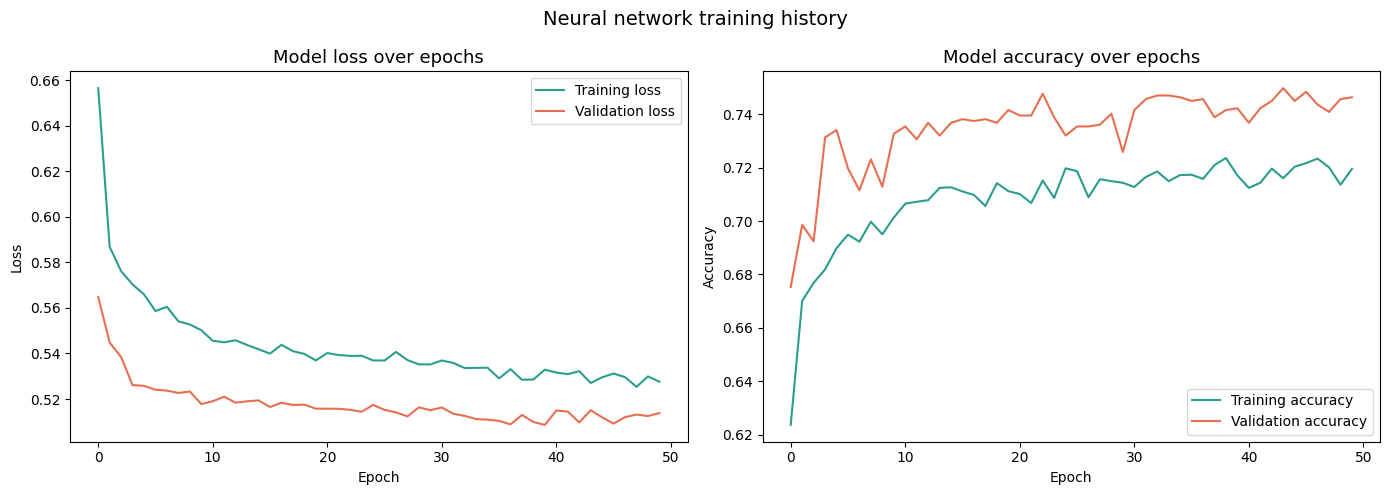

Total epochs trained: 50
Best val accuracy: 74.98%


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Loss
axes[0].plot(history.history['loss'], color='#2a9d8f', label='Training loss')
axes[0].plot(history.history['val_loss'], color='#e76f51', label='Validation loss')
axes[0].set_title('Model loss over epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Plot 2 - Accuracy
axes[1].plot(history.history['accuracy'], color='#2a9d8f', label='Training accuracy')
axes[1].plot(history.history['val_accuracy'], color='#e76f51', label='Validation accuracy')
axes[1].set_title('Model accuracy over epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Neural network training history', fontsize=14)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Total epochs trained: {len(history.history['loss'])}")
print(f"Best val accuracy: {max(history.history['val_accuracy'])*100:.2f}%")

In [11]:
import pickle

model.save('reelrejects_nn_model.keras')

with open('nn_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("saved nn model and scaler")
print(f"nn test acc: {acc*100:.2f}%, xgb was 73.42%")
print("xgboost still better for deployment but nn was close")

saved nn model and scaler
nn test acc: 71.21%, xgb was 73.42%
xgboost still better for deployment but nn was close
